<h1 style="height:60px;">Training and Evaluating ModelNetV2 and ResNet34</h1>

In [1]:
from torchvision.datasets import ImageFolder
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,random_split
from torchvision import transforms,models,datasets
import matplotlib.pyplot as plt
import numpy as np
from torch import optim
import os
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns


preprocess=transforms.Compose(
    [
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
         mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
]
)

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset=ImageFolder(
    os.path.abspath("caltech101"),
    transform=preprocess,
)
total_size=len(dataset)
train_size=int(0.7*total_size)
val_size=int(0.15*total_size)
test_size=total_size-train_size-val_size

train_dataset,val_dataset,test_dataset=random_split(dataset,[train_size,val_size,test_size])
train_loader=DataLoader(train_dataset,batch_size=64,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=64,shuffle=False)
test_loader=DataLoader(test_dataset,batch_size=64,shuffle=False)

criterion=nn.CrossEntropyLoss()

model1=models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
model2=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

num_classes=len(dataset.classes)
model1.fc=nn.Linear(model1.fc.in_features,num_classes)
model2.classifier[1]=nn.Linear(model2.classifier[1].in_features,num_classes)

model1=model1.to(device)
model2=model2.to(device)

print(device)
for i in model1.parameters():
    i.requires_grad=False
for i in model1.fc.parameters():
    i.requires_grad=True


for i in model2.parameters():
    i.requires_grad=False
for i in model2.classifier[1].parameters():
    i.requires_grad=True

optimizer1=optim.Adam(model1.fc.parameters(),lr=0.003)
optimizer2=optim.Adam(model2.classifier[1].parameters())
epochs=3

for epoch in range(epochs):

    model1.train()
    running_loss1=0
    total=0
    correct_answer=0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer1.zero_grad()
        output1=model1(images)
        loss1=criterion(output1,labels)
        loss1.backward()
        optimizer1.step()
        running_loss1+=loss1.item()*labels.size(0)
        total+=labels.size(0)
        probability,classes=torch.max(output1,1)
        correct_answer+=(classes==labels).sum().item()
    print(f"Training Loss Model 1: {running_loss1/total}")
    print(f"Training Accuracy Model 1: {(correct_answer/total)*100}%")
    print("")
    model1.eval()
    with torch.no_grad():
        running_loss1=0
        correct_answer=0
        total=0
        for images,labels in val_loader:
            images,labels=images.to(device),labels.to(device)
            output1=model1(images)
            loss1=criterion(output1,labels)
            running_loss1+=loss1.item()*labels.size(0)
            probability,classes=torch.max(output1,1)
            total+=labels.size(0)
            correct_answer+=(classes==labels).sum().item()
        print(f"Evaluation Loss Model 1: {running_loss1/total}")
        print(f"Evaluation Accuracy Model 1: {(correct_answer/total)*100}%")
        print("")



            

       
for epoch in range(epochs):

    model2.train()
    total=0
    running_loss2=0
    correct_answer=0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        optimizer2.zero_grad()
        output2=model2(images)
        loss2=criterion(output2,labels)
        loss2.backward()
        optimizer2.step()
        running_loss2+=loss2.item()*labels.size(0)
        total+=labels.size(0)
        probability,classes=torch.max(output2,1)
      
        correct_answer+=(classes==labels).sum().item()
    print(f"Training Loss Model 2: {running_loss2/total}")
    print(f"Training Accuracy Model 2: {(correct_answer/total)*100}%")
    print("")
    model2.eval()
    with torch.no_grad():
        running_loss2=0
        correct_answer=0
        total=0
        for images,labels in val_loader:
            images,labels=images.to(device),labels.to(device)
            output2=model2(images)
            loss2=criterion(output2,labels)
            running_loss2+=loss2.item()*labels.size(0)
            probability,classes=torch.max(output2,1)
            total+=labels.size(0)
            correct_answer+=(classes==labels).sum().item()
            
        print(f"Evaluation Loss Model 2: {(running_loss2/total)}")
        print(f"Evaluation Accuracy Model 2: {(correct_answer/total)*100}%")
        print("")



cuda
Training Loss Model 1: 1.4733578664064408
Training Accuracy Model 1: 69.65625%

Evaluation Loss Model 1: 0.4505499298341252
Evaluation Accuracy Model 1: 90.0802334062728%

Training Loss Model 1: 0.32526377111673355
Training Accuracy Model 1: 92.421875%

Evaluation Loss Model 1: 0.3511468158813396
Evaluation Accuracy Model 1: 91.17432530999271%

Training Loss Model 1: 0.19288181193172932
Training Accuracy Model 1: 95.6875%

Evaluation Loss Model 1: 0.34453237043146145
Evaluation Accuracy Model 1: 90.29905178701677%

Training Loss Model 2: 2.512065517902374
Training Accuracy Model 2: 51.390625%

Evaluation Loss Model 2: 1.3382793621456945
Evaluation Accuracy Model 2: 80.81692195477753%

Training Loss Model 2: 0.8884118777513504
Training Accuracy Model 2: 87.328125%

Evaluation Loss Model 2: 0.725176445764838
Evaluation Accuracy Model 2: 88.03792851932896%

Training Loss Model 2: 0.5267276015877723
Training Accuracy Model 2: 92.15625%

Evaluation Loss Model 2: 0.5466358580352789
Eval

<h1 style="height:60px;">Applying FGSM Adversarial Attack</h1>

Before Injecting FGSM
Model 1 Test Accuracy: 92.86234522942462%
Model 1 Testing Loss: 0.2700770280804846

After Injecting FGSM
Model 1 Test Accuracy: 35.61544064093226%
Model 1 Testing Loss: 2.7493234696565367

Before Injecting FGSM
Model 2 Test Accuracy: 90.53168244719592%
Model 2 Testing Loss: 0.52117069316275

After Injecting FGSM
Model 2 Test Accuracy: 39.32993445010925%
Model 2 Testing Loss: 2.6616723919470466



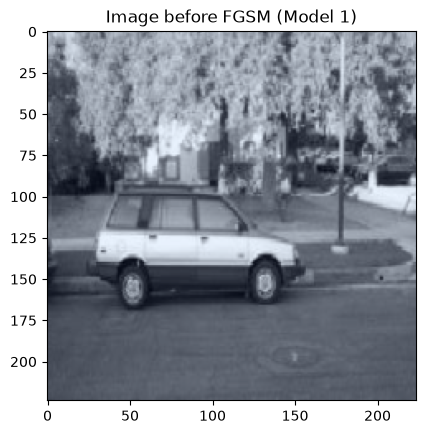

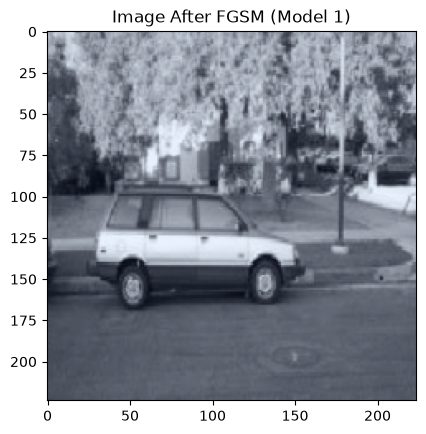

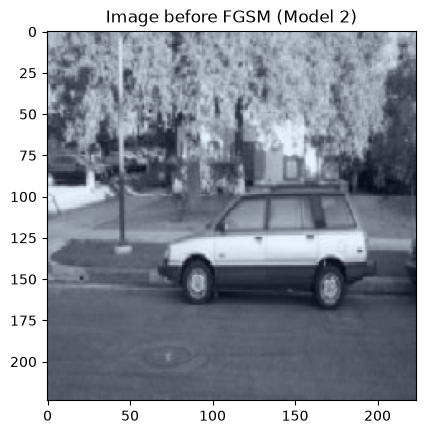

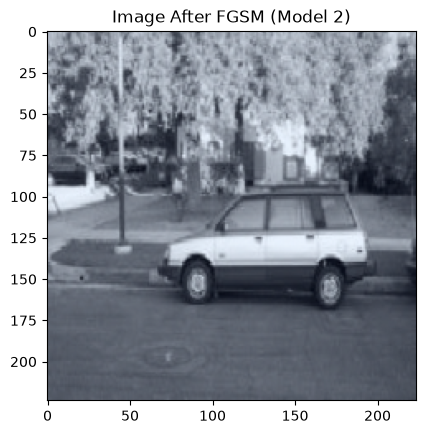

In [2]:
def new_img(image,gradient,epsilon):
    return image+epsilon*gradient.sign()

import sys

def clip(images):
    img = images.clone()
    img -= img.min()
    img /= (img.max()-img.min() + 1e-7)
    return img






running_loss1=0
correct=0
total=0
running_loss1_2=0
correct2=0
model1.eval()
batch=0
gradients_1=[]
gradients_2=[]
gradients_3=[]
gradients_4=[]
for images,labels in test_loader:
    
    batch+=1
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    output1=model1(images)
    loss1=criterion(output1,labels)
    model1.zero_grad()
    running_loss1+=loss1.item()*labels.size(0)
    total+=labels.size(0)
    probability,classes=torch.max(output1,1)
    correct+=(labels==classes).sum().item()
    loss1.backward()
    gradient_values,gradient_indices=images.grad.abs().max(dim=1)
    gradients_1.append(clip(gradient_values).cpu().detach().numpy()[0]) #first image
    if batch<2:
        plt.figure()
        plt.imshow(clip(images.permute(0,2,3,1)).cpu().detach().numpy()[0])
        plt.title("Image before FGSM (Model 1)")


    adversary_img=new_img(images,images.grad,0.01)
    adversary_img.retain_grad() #Non leaf tensor (Result of a leaf tensor (original image ))
    output1_2=model1(adversary_img)
    loss1_2=criterion(output1_2,labels)
    model1.zero_grad()
    probability2,classes2=torch.max(output1_2,1)
    class_score=output1_2[0,classes[0]]
    class_score.backward()
    gradient_values,gradient_indices=adversary_img.grad.abs().max(dim=1)
    gradients_3.append(clip(gradient_values).cpu().detach().numpy()[0]) #first image
    
    correct2+=(classes2==labels).sum().item()
    running_loss1_2+=loss1_2.item()*labels.size(0)
    if batch<2:
        plt.figure()
        plt.imshow(clip(adversary_img.permute(0,2,3,1)).cpu().detach().numpy()[0])
        plt.title("Image After FGSM (Model 1)")

print("Before Injecting FGSM")
print(f"Model 1 Test Accuracy: {(correct/total)*100}%")
print(f"Model 1 Testing Loss: {running_loss1/total}")          
print("")
print("After Injecting FGSM")
print(f"Model 1 Test Accuracy: {(correct2/total)*100}%")
print(f"Model 1 Testing Loss: {running_loss1_2/total}")          
print("")
















running_loss2=0
correct=0
total=0
running_loss2_2=0
correct2=0
model2.eval()
batch=0
for images,labels in test_loader:
    batch+=1
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    output2=model2(images)
    loss2=criterion(output2,labels)
    model2.zero_grad()
    running_loss2+=loss2.item()*labels.size(0)
    total+=labels.size(0)
    probability,classes=torch.max(output2,1)
    correct+=(labels==classes).sum().item()
    loss2.backward()
    gradient_values,gradient_indices=images.grad.abs().max(dim=1)
    gradients_2.append(clip(gradient_values).cpu().detach().numpy()[0]) #first image
    if batch<2:
        plt.figure()
        plt.imshow(clip(images.permute(0,2,3,1)).cpu().detach().numpy()[0])
        plt.title("Image before FGSM (Model 2)")

    adversary_img=new_img(images,images.grad,0.01)
    adversary_img.retain_grad()
    output2_2=model2(adversary_img)
    loss2_2=criterion(output2_2,labels)
    model2.zero_grad()
    probability2,classes2=torch.max(output2_2,1)
    class_score=output2_2[0,classes[0]]
    class_score.backward()
    gradient_values,gradient_indices=adversary_img.grad.abs().max(dim=1)
    gradients_4.append(clip(gradient_values).cpu().detach().numpy()[0]) #first image
   
    correct2+=(classes2==labels).sum().item()
    running_loss2_2+=loss2_2.item()*labels.size(0)
    if batch<2:
        plt.figure()
        plt.imshow(clip(adversary_img.permute(0,2,3,1)).cpu().detach().numpy()[0])
        plt.title("Image After FGSM (Model 2)")
print("Before Injecting FGSM")
print(f"Model 2 Test Accuracy: {(correct/total)*100}%")
print(f"Model 2 Testing Loss: {running_loss2/total}")          
print("")
print("After Injecting FGSM")
print(f"Model 2 Test Accuracy: {(correct2/total)*100}%")
print(f"Model 2 Testing Loss: {running_loss2_2/total}")          
print("")













Notice there's no difference in the images yet the accuracy significantly dropped
this is because FGSM aims to deliberately increase the loss from each pixel by making it go in the direction of the loss function's gradient
to clarify the weight update formula is W(new)=W(old)-dLoss/dWeight*LR
so if the loss function is decreasing you increase your weights and vice versa which decreases the loss each time
the exact opposite happens with FGSM

Text(0.5, 1.0, 'Saliency map (Model 2) After FGSM')

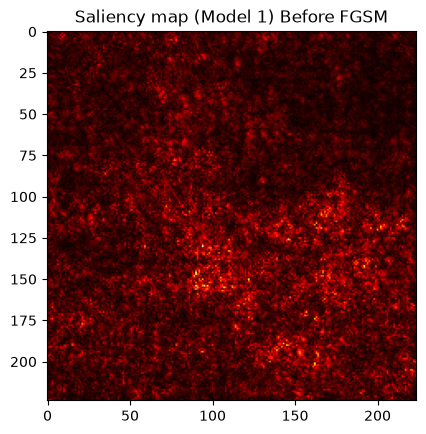

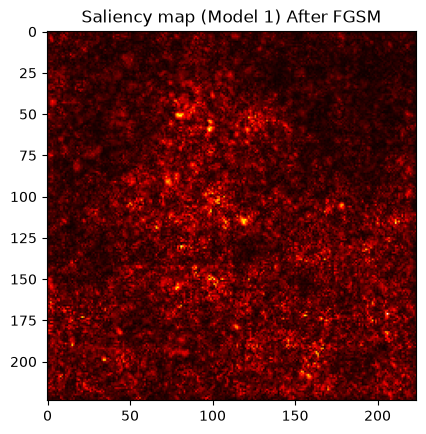

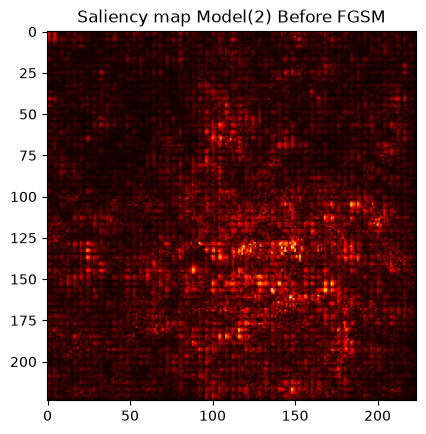

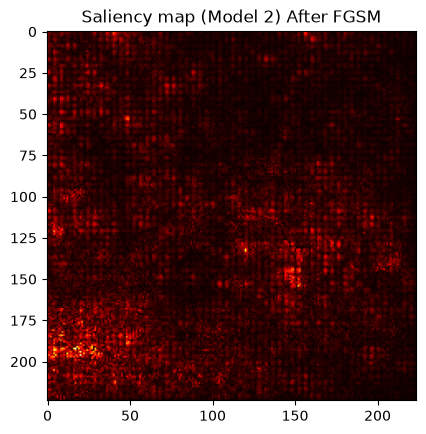

In [3]:
plt.figure()
plt.imshow(gradients_1[0],cmap="hot") #first image from the first batch
plt.title("Saliency map (Model 1) Before FGSM")

plt.figure()
plt.imshow(gradients_3[0],cmap="hot") #first image from the first batch
plt.title("Saliency map (Model 1) After FGSM")

plt.figure()
plt.imshow(gradients_2[0],cmap="hot") #first image from the first batch
plt.title("Saliency map Model(2) Before FGSM")

plt.figure()
plt.imshow(gradients_4[0],cmap="hot") #first image from the first batch
plt.title("Saliency map (Model 2) After FGSM")



Model 1 Test Accuracy: 93.75%
Model 1 Testing Loss: 0.20839792490005493
Model 2 Test Accuracy: 93.75%
Model 2 Testing Loss: 0.4011182188987732


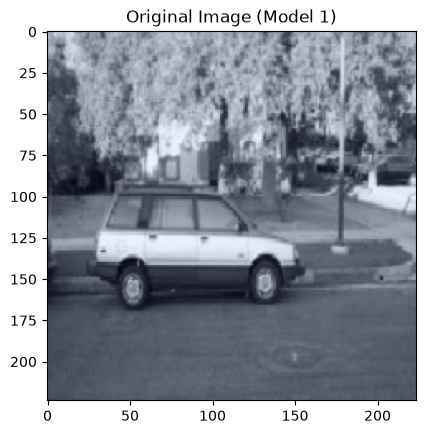

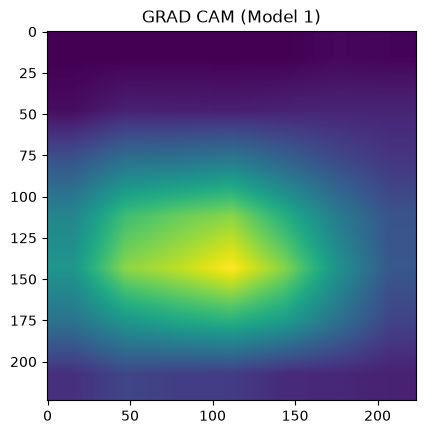

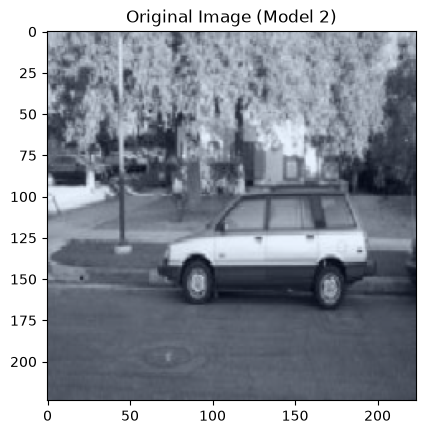

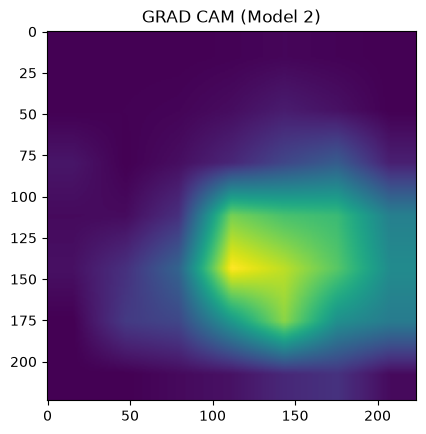

In [4]:
import torch.nn.functional as F
running_loss1=0
correct=0
total=0
running_loss1_2=0
correct2=0
model1.eval()
batch=0
gradients_1=[]
gradients_2=[]
feature_map=[[]]
feature_map_2=[[]]
grad_cam1=[]
grad_cam3=[]
def forward_hook(module,input,output):
    feature_map[0]=output
    feature_map[0].retain_grad()

def forward_hook2(module,input,output):
    feature_map_2[0]=output
    feature_map_2[0].retain_grad()   
hook1=model1.layer4.register_forward_hook(forward_hook)    
hook2=model2.features[-1].register_forward_hook(forward_hook2)

for images,labels in test_loader:
    
    batch+=1
    if batch<2:
        images,labels=images.to(device),labels.to(device)
        images.requires_grad=True
        output1=model1(images)
        loss1=criterion(output1,labels)
        running_loss1+=loss1.item()*labels.size(0)
        total+=labels.size(0)
        probability,classes=torch.max(output1,1)
        correct+=(labels==classes).sum().item()
  
        model1.zero_grad()
        class_score=output1[0,classes[0]] #first image
        class_score.backward()
        image_features=feature_map[0]
        first_image_gradient_mean=image_features.grad[0].mean(dim=(1,2))
        first_image_gradient_weighted=first_image_gradient_mean[:,None,None]*image_features[0] #Broadcasting
        grad_cam1=first_image_gradient_weighted.sum(dim=0)
        grad_cam1=F.relu(grad_cam1)
        grad_cam1=grad_cam1.unsqueeze(0).unsqueeze(0) #interpolate expects 4Dim 
        grad_cam1=F.interpolate(
            grad_cam1,
            size=(images[0].shape[1],images[0].shape[2]),
            mode="bilinear",
            align_corners=False
        )
        grad_cam1=grad_cam1.squeeze(0).squeeze(0) #Return to 2DIM
        plt.figure()
        plt.imshow(clip(images[0]).permute(1,2,0).cpu().detach().numpy())
        plt.title("Original Image (Model 1)")
        plt.figure()
        plt.imshow(clip(grad_cam1).cpu().detach().numpy())
        plt.title("GRAD CAM (Model 1)")
            

    


   



    

print(f"Model 1 Test Accuracy: {(correct/total)*100}%")
print(f"Model 1 Testing Loss: {running_loss1/total}")          

















running_loss2=0
correct=0
total=0
running_loss2_2=0
correct2=0
model2.eval()
batch=0
grad_cam_2=[]
for images,labels in test_loader:
    batch+=1
    if batch<2:
        images,labels=images.to(device),labels.to(device)
        images.requires_grad=True
        output2=model2(images)
        loss2=criterion(output2,labels)
        running_loss2+=loss2.item()*labels.size(0)
        total+=labels.size(0)
        probability,classes=torch.max(output2,1)
        correct+=(labels==classes).sum().item()
  
        model2.zero_grad()
        class_score=output2[0,classes[0]] #first image
        class_score.backward()

        image_features=feature_map_2[0]
        first_image_gradient_mean=image_features.grad[0].mean(dim=(1,2))
        first_image_gradient_weighted=first_image_gradient_mean[:,None,None]*image_features[0] #Broadcasting
        grad_cam_2=first_image_gradient_weighted.sum(dim=0)
        grad_cam_2=F.relu(grad_cam_2)
        grad_cam_2=grad_cam_2.unsqueeze(0).unsqueeze(0)
        grad_cam_2=F.interpolate(
            grad_cam_2,
            size=(images[0].shape[1],images[0].shape[2]),
            mode="bilinear",
            align_corners=False
        )
        grad_cam_2=grad_cam_2.squeeze(0).squeeze(0)
        plt.figure()
        plt.imshow(clip(images[0]).permute(1,2,0).cpu().detach().numpy())
        plt.title("Original Image (Model 2)")
        plt.figure()
        plt.imshow(clip(grad_cam_2).cpu().detach().numpy())
        plt.title("GRAD CAM (Model 2)")
        
    

    

print(f"Model 2 Test Accuracy: {(correct/total)*100}%")
print(f"Model 2 Testing Loss: {running_loss2/total}")          
hook1.remove()
hook2.remove()






Lets run it on the adversary images

Model 1 Test Accuracy: 34.375%
Model 1 Testing Loss: 2.692288637161255
Model 2 Test Accuracy: 43.75%
Model 2 Testing Loss: 2.4080867767333984


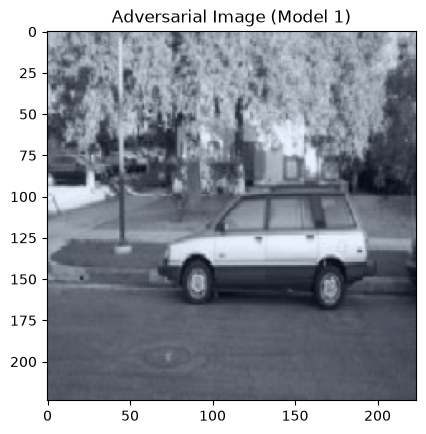

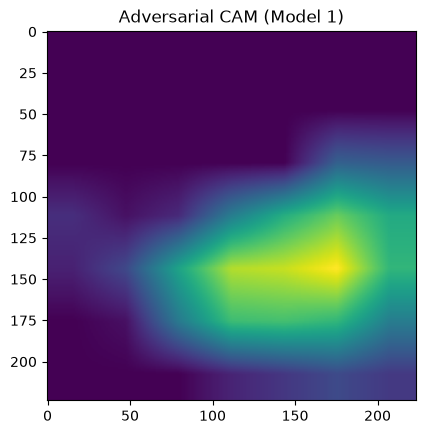

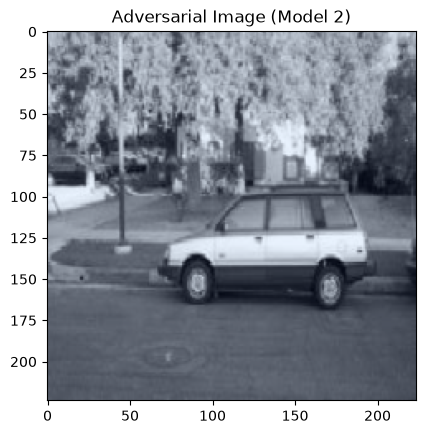

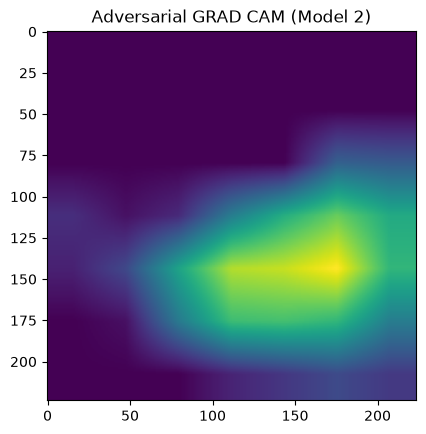

In [5]:
import torch.nn.functional as F
running_loss1=0
correct=0
total=0
running_loss1_2=0
correct2=0
model1.eval()
batch=0
gradients_1=[]
gradients_2=[]
feature_map=[[]]
feature_map_2=[[]]
grad_cam1=[]
grad_cam3=[]
def forward_hook(module,input,output):
    feature_map[0]=output
    feature_map[0].retain_grad()

def forward_hook2(module,input,output):
    feature_map_2[0]=output
    feature_map_2[0].retain_grad()   
hook1=model1.layer4.register_forward_hook(forward_hook)    
hook2=model2.features[-1].register_forward_hook(forward_hook2)

for images,labels in test_loader:
    
    batch+=1
    if batch<2:
        images,labels=images.to(device),labels.to(device)
        images.requires_grad=True
        model1.zero_grad()
        output1=model1(images)
        loss1=criterion(output1,labels)
        loss1.backward()
        adversary_img=new_img(images,images.grad,0.01)
        model1.zero_grad()
        output1=model1(adversary_img)
        loss1=criterion(output1,labels)
        probability,classes=torch.max(output1,1)
        class_score=output1[0,classes[0]] #first image
        class_score.backward()
        image_features=feature_map[0]
        first_image_gradient_mean=image_features.grad[0].mean(dim=(1,2))
        first_image_gradient_weighted=first_image_gradient_mean[:,None,None]*image_features[0] #Broadcasting
        grad_cam1=first_image_gradient_weighted.sum(dim=0)
        grad_cam1=F.relu(grad_cam1)
        grad_cam1=grad_cam1.unsqueeze(0).unsqueeze(0) #interpolate expects 4Dim 
        grad_cam1=F.interpolate(
            grad_cam1,
            size=(adversary_img[0].shape[1],images[0].shape[2]),
            mode="bilinear",
            align_corners=False
        )
        grad_cam1=grad_cam1.squeeze(0).squeeze(0) #Return to 2DIM
        total+=labels.size(0)
        running_loss1+=loss1.item()*labels.size(0)
        correct+=(labels==classes).sum().item()

        plt.figure()
        plt.imshow(clip(images[0]).permute(1,2,0).cpu().detach().numpy())
        plt.title("Adversarial Image (Model 1)")
        plt.figure()
        plt.imshow(clip(grad_cam1).cpu().detach().numpy())
        plt.title("Adversarial CAM (Model 1)")
            

    


   



    

print(f"Model 1 Test Accuracy: {(correct/total)*100}%")
print(f"Model 1 Testing Loss: {running_loss1/total}")          
















running_loss2=0
correct=0
total=0
running_loss2_2=0
correct2=0
model2.eval()
batch=0
grad_cam_2=[]

for images,labels in test_loader:
    
    batch+=1
    if batch<2:
        images,labels=images.to(device),labels.to(device)
        images.requires_grad=True
        model2.zero_grad()
        output2=model2(images)
        loss2=criterion(output2,labels)
        loss2.backward()
        adversary_img=new_img(images,images.grad,0.01)
        model2.zero_grad()
        output2=model2(adversary_img)
        loss2=criterion(output2,labels)
        probability,classes=torch.max(output2,1)
        class_score=output2[0,classes[0]] #first image
        class_score.backward()
        image_features=feature_map_2[0]
        first_image_gradient_mean=image_features.grad[0].mean(dim=(1,2))
        first_image_gradient_weighted=first_image_gradient_mean[:,None,None]*image_features[0] #Broadcasting
        grad_cam2=first_image_gradient_weighted.sum(dim=0)
        grad_cam2=F.relu(grad_cam2)
        grad_cam2=grad_cam2.unsqueeze(0).unsqueeze(0) #interpolate expects 4Dim 
        grad_cam2=F.interpolate(
            grad_cam2,
            size=(adversary_img[0].shape[1],images[0].shape[2]),
            mode="bilinear",
            align_corners=False
        )
        grad_cam2=grad_cam2.squeeze(0).squeeze(0) #Return to 2DIM
        total+=labels.size(0)
        running_loss2+=loss2.item()*labels.size(0)
        correct+=(labels==classes).sum().item()

        plt.figure()
        plt.imshow(clip(images[0]).permute(1,2,0).cpu().detach().numpy())
        plt.title("Adversarial Image (Model 2)")
        plt.figure()
        plt.imshow(clip(grad_cam1).cpu().detach().numpy())
        plt.title("Adversarial GRAD CAM (Model 2)")
            

    


   
    

print(f"Model 2 Test Accuracy: {(correct/total)*100}%")
print(f"Model 2 Testing Loss: {running_loss2/total}")          
hook1.remove()
hook2.remove()






We can easily tell that grad-cam is less sensitive to adversarial attacks due to its average pooling..taking the average of each gradient and multiplying it then summing all features makes it less sensitive to changes
rather than just taking the gradient then max-pooling it which explains why saliency maps are more sensitive to adversarial attacks

<h1 style="height:60px">Defensive  Counter-measures</h1>
Lets create the models from scratch and train them on adversarial attacks 

In [ ]:

model1=models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
model2=models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

num_classes=len(dataset.classes)
model1.fc=nn.Linear(model1.fc.in_features,num_classes)
model2.classifier[1]=nn.Linear(model2.classifier[1].in_features,num_classes)

model1=model1.to(device)
model2=model2.to(device)

print(device)
for i in model1.parameters():
    i.requires_grad=False
for i in model1.fc.parameters():
    i.requires_grad=True


for i in model2.parameters():
    i.requires_grad=False
for i in model2.classifier[1].parameters():
    i.requires_grad=True

optimizer1=optim.Adam(model1.fc.parameters(),lr=0.003)
optimizer2=optim.Adam(model2.classifier[1].parameters())
epochs=10

for epoch in range(epochs):

    model1.train()
    running_loss1=0
    total=0
    correct_answer=0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        images.requires_grad=True
        output1=model1(images)
        loss=criterion(output1,labels)
        model1.zero_grad()
        loss.backward()
        adversary_img=new_img(images,images.grad,0.01).detach()
        model1.zero_grad()
        optimizer1.zero_grad()
        output1=model1(images)
        output1_2=model1(adversary_img)
        loss1=criterion(output1,labels)
        loss1_2=criterion(output1_2,labels)
        total_loss1=loss1*0.5+loss1_2*0.5
        total_loss1.backward()
        optimizer1.step()

        running_loss1+=total_loss1.item()*labels.size(0)
        total+=labels.size(0)*2
        probability,classes=torch.max(output1,1)
        probability2,classes2=torch.max(output1_2,1)
        correct_answer+=(classes==labels).sum().item()+(classes2==labels).sum().item()



       

    print(f"Training Loss Model 1: {running_loss1/total}")
    print(f"Training Accuracy Model 1: {(correct_answer/total)*100}%")
    print("")

model1.eval()
running_loss1=0
correct_answer=0
total=0
for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    output1=model1(images)
    loss1=criterion(output1,labels)
    model1.zero_grad()
    loss1.backward()
    adv_images=new_img(images,images.grad,0.01).detach()
    model1.zero_grad()
    output1=model1(adv_images)
    loss1=criterion(output1,labels)
    running_loss1+=loss1.item()*labels.size(0)
    probability,classes=torch.max(output1,1)
    total+=labels.size(0)
    correct_answer+=(classes==labels).sum().item()

print(f"Test Loss Model 1: {running_loss1/total}")
print(f"Test Accuracy Model 1: {(correct_answer/total)*100}%")
print("")










for epoch in range(epochs):

    model2.train()
    running_loss2=0
    total=0
    correct_answer=0

    for images,labels in train_loader:
        images,labels=images.to(device),labels.to(device)
        images.requires_grad=True
        output2=model2(images)
        loss=criterion(output2,labels)
        model2.zero_grad()
        loss.backward()
        adversary_img=new_img(images,images.grad,0.01).detach()
        model2.zero_grad()
        optimizer2.zero_grad()
        output2=model2(images)
        output2_2=model2(adversary_img)
        loss2=criterion(output2,labels)
        loss2_2=criterion(output2_2,labels)
        total_loss2=loss2*0.5+loss2_2*0.5
        total_loss2.backward()
        optimizer2.step()
        running_loss2+=total_loss2.item()*labels.size(0)
        total+=labels.size(0)*2
        probability,classes=torch.max(output2,1)
        probability2,classes2=torch.max(output2_2,1)
        correct_answer+=(classes==labels).sum().item()+(classes2==labels).sum().item()



       

    print(f"Training Loss Model 2: {running_loss2/total}")
    print(f"Training Accuracy Model 2: {(correct_answer/total)*100}%")
    print("")

model2.eval()
running_loss2=0
correct_answer=0
total=0
for images,labels in test_loader:
    images,labels=images.to(device),labels.to(device)
    images.requires_grad=True
    output2=model2(images)
    loss2=criterion(output2,labels)
    model2.zero_grad()
    loss2.backward()
    adv_images=new_img(images,images.grad,0.01).detach()
    model2.zero_grad()
    output2=model2(adv_images)
    loss2=criterion(output2,labels)
    running_loss2+=loss2.item()*labels.size(0)
    probability,classes=torch.max(output2,1)
    total+=labels.size(0)
    correct_answer+=(classes==labels).sum().item()

print(f"Test Loss Model 2: {running_loss2/total}")
print(f"Test Accuracy Model 2: {(correct_answer/total)*100}%")
print("")





















cuda
Training Loss Model 1: 1.1535470455884933
Training Accuracy Model 1: 51.125%

Training Loss Model 1: 0.5598376846313476
Training Accuracy Model 1: 71.1796875%

